In [6]:
from sklearn.model_selection import train_test_split

x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(x_train[0])

(426, 30)
(143, 30)
[1.289e+01 1.312e+01 8.189e+01 5.159e+02 6.955e-02 3.729e-02 2.260e-02
 1.171e-02 1.337e-01 5.581e-02 1.532e-01 4.690e-01 1.115e+00 1.268e+01
 4.731e-03 1.345e-02 1.652e-02 5.905e-03 1.619e-02 2.081e-03 1.362e+01
 1.554e+01 8.740e+01 5.770e+02 9.616e-02 1.147e-01 1.186e-01 5.366e-02
 2.309e-01 6.915e-02]


In [7]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)
print(log_reg.score(x_train, y_train))
print(log_reg.score(x_test, y_test))

0.9436619718309859
0.965034965034965


/Users/xusu/opt/miniconda3/envs/ai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression())
])
pipeline.fit(x_train, y_train)
print(pipeline.score(x_train, y_train))
print(pipeline.score(x_test, y_test))

0.9859154929577465
0.9790209790209791


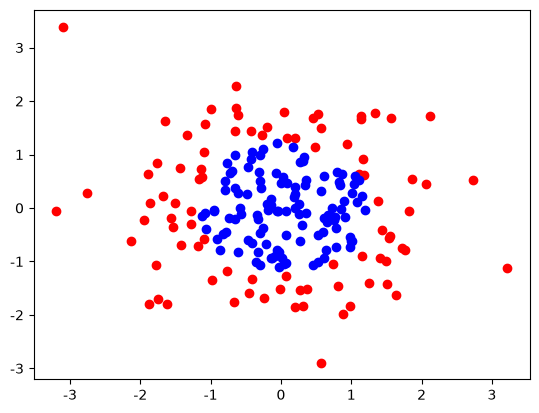

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(666)
X = np.random.normal(0, 1, size=(200, 2))
y = np.array(X[:, 0]**2 + X[:, 1]**2 < 1.5, dtype=int)

plt.scatter(X[y==0, 0], X[y==0, 1], color='red')
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue')
plt.show()

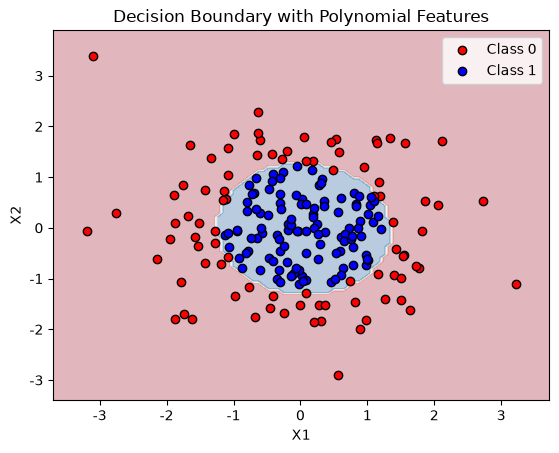

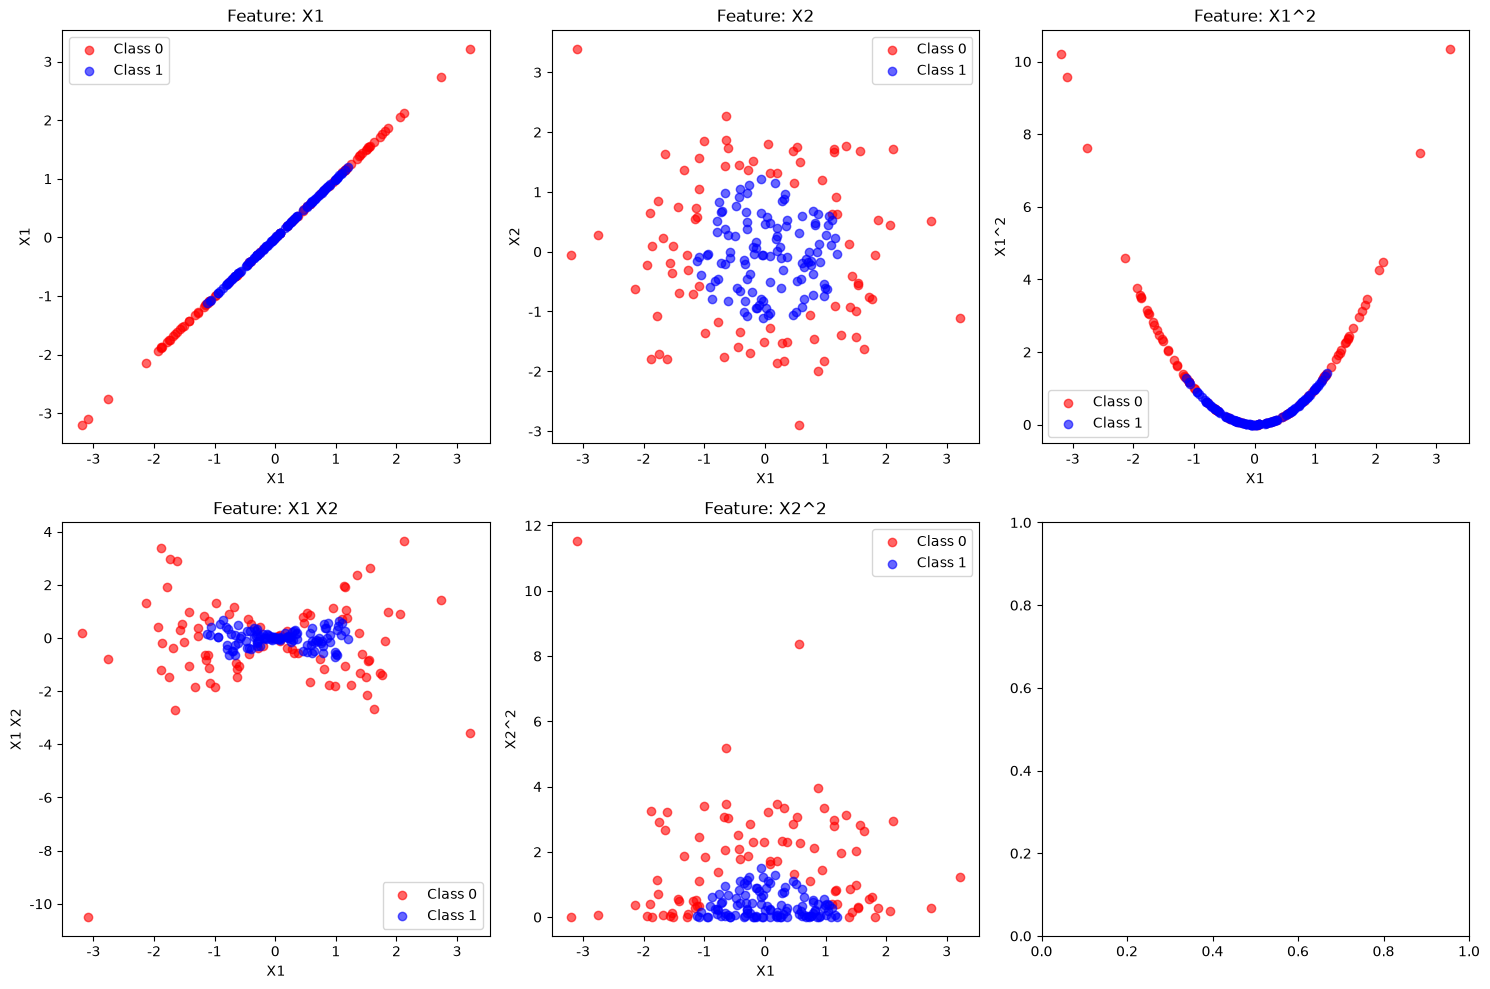

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

np.random.seed(666)
X = np.random.normal(0, 1, size=(200, 2))
y = np.array(X[:, 0]**2 + X[:, 1]**2 < 1.5, dtype=int)

# 创建多项式特征
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 训练逻辑回归模型
model = LogisticRegression()
model.fit(X_poly, y)

# 绘制决策边界
def plot_decision_boundary(model, X, y, poly):
    # 创建网格
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # 将网格点转换为多项式特征
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_poly = poly.transform(grid_points)
    
    # 预测
    Z = model.predict(grid_poly)
    Z = Z.reshape(xx.shape)
    
    # 绘制
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[y==0, 0], X[y==0, 1], color='red', label='Class 0', edgecolors='black')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Class 1', edgecolors='black')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.title('Decision Boundary with Polynomial Features')
    plt.show()

plot_decision_boundary(model, X, y, poly)

# 显示多项式特征的值
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
feature_names = poly.get_feature_names_out(['X1', 'X2'])

for i, ax in enumerate(axes.flat):
    if i < X_poly.shape[1]:
        # 对每个多项式特征按类别绘制
        for class_val in [0, 1]:
            mask = y == class_val
            ax.scatter(X[mask, 0], X_poly[mask, i], 
                      label=f'Class {class_val}', 
                      color=['red', 'blue'][class_val], 
                      alpha=0.6)
        ax.set_xlabel('X1')
        ax.set_ylabel(feature_names[i])
        ax.legend()
        ax.set_title(f'Feature: {feature_names[i]}')

plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import PolynomialFeatures

def PolynomialLogisticRegression(degree, C=1):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('std_scaler', StandardScaler()),
        ('log_reg', LogisticRegression(C=C))
    ])

poly_log_reg = PolynomialLogisticRegression(degree=2)
poly_log_reg.fit(x_train, y_train)
print(poly_log_reg.score(x_train, y_train))
print(poly_log_reg.score(x_test, y_test))

0.9929577464788732
0.972027972027972


In [ ]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
print(log_reg.score(X_test, y_test))

1.0


In [27]:
import joblib

x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression())
])
pipeline.fit(x_train, y_train)
joblib.dump(pipeline, 'cancer.pkl')

['cancer.pkl']

In [28]:
model = joblib.load('cancer.pkl')
print(model.score(x_test, y_test))
result = model.predict(x_test)
print(result.shape)

0.9790209790209791
(143,)


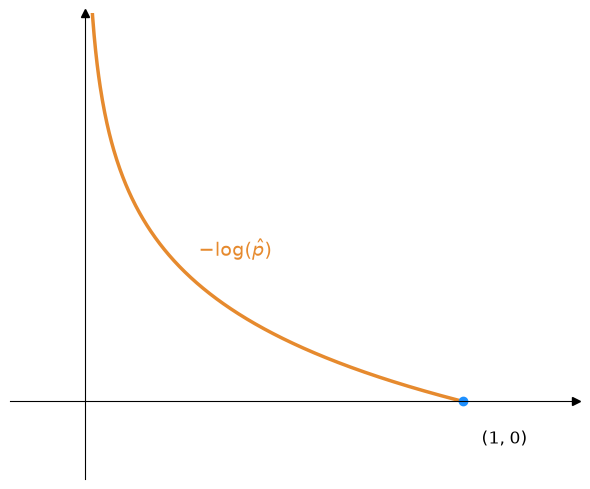

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 设置绘图风格与字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  
plt.rcParams['axes.unicode_minus'] = False

# 生成 \hat{p} 的数据点 (0, 1]
p_hat = np.linspace(0.001, 1.0, 500)
y = -np.log(p_hat)

fig, ax = plt.subplots(figsize=(6, 5))

# 绘制坐标轴 (Crossed at 0,0)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 添加坐标轴箭头
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

# 绘制 -\log(\hat{p}) 曲线 (橙色)
ax.plot(p_hat, y, color='#E68A2E', linewidth=2.5, label=r'$-\log(\hat{p})$')

# 标记端点 (1, 0)
ax.plot(1, 0, marker='o', markersize=6, color='#1E90FF')
ax.text(1.05, -0.3, '(1, 0)', fontsize=12, verticalalignment='top')

# 标注曲线名称
ax.text(0.3, 1.5, r'$-\log(\hat{p})$', color='#E68A2E', fontsize=14, fontweight='bold')

# 设置坐标轴范围与标签
ax.set_xlim(-0.2, 1.3)
ax.set_ylim(-0.8, 4.0)

# 隐藏默认刻度值，保持简洁风格
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig("log_loss_curve.png", dpi=300)
plt.show()